# nb03_twopx_baseline_models (v10 Phase E)

Loads and visualizes Phase E twopx (paired opx+cpx) training results. 64 Optuna studies (8 models x 2 targets x 1 track x 4 feature sets), zero failures. Twopx has a dedicated feature set `twopx_components` on top of raw/alr/pwlr.


In [1]:
import os, sys
from pathlib import Path
ROOT = Path.cwd()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
os.chdir(ROOT)
sys.path.insert(0, str(ROOT))

import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from config import RESULTS
pd.set_option('display.width', 200)
pd.set_option('display.max_columns', 50)


## Base model results (64 rows)


In [2]:
df_bases = pd.read_csv(RESULTS / 'v10_twopx_per_cell_results.csv')
print(f'n_rows={len(df_bases)}')
df_bases.round(3)


n_rows=64


,model,target,track,feature_set,test_rmse,test_r2,cv_rmse
0,RF,T_C,twopx,raw,87.877,0.347,71.444
1,ERT,T_C,twopx,raw,87.799,0.349,73.277
2,XGB,T_C,twopx,raw,102.526,0.112,66.863
3,GB,T_C,twopx,raw,105.733,0.055,69.636
4,CatBoost,T_C,twopx,raw,92.104,0.283,68.985
...,...,...,...,...,...,...,...
59,GB,P_kbar,twopx,twopx_components,5.254,0.135,4.754
60,CatBoost,P_kbar,twopx,twopx_components,5.625,0.008,4.976
61,LightGBM,P_kbar,twopx,twopx_components,5.422,0.078,4.629
62,ElasticNet,P_kbar,twopx,twopx_components,5.749,-0.036,6.267


## Ensemble results


In [3]:
df_ens = pd.read_csv(RESULTS / 'v10_twopx_ensemble_results.csv')
df_ens.round(3)


,method,target,track,feature_set,test_rmse
0,ridge,T_C,twopx,raw,102.581
1,two_level,T_C,twopx,raw,98.961
2,greedy,T_C,twopx,raw,92.789
3,ridge,T_C,twopx,alr,88.612
4,two_level,T_C,twopx,alr,91.191
5,greedy,T_C,twopx,alr,89.200
6,ridge,T_C,twopx,pwlr,93.214
7,two_level,T_C,twopx,pwlr,85.741
8,greedy,T_C,twopx,pwlr,81.040
9,ridge,T_C,twopx,twopx_components,97.624


## Best base per (target, feature_set)


In [4]:
idx = df_bases.groupby(['target','feature_set'])['test_rmse'].idxmin()
best_per_cell = df_bases.loc[idx].reset_index(drop=True)
best_per_cell[['target','track','model','feature_set','test_rmse','test_r2']].round(3)


,target,track,model,feature_set,test_rmse,test_r2
0,P_kbar,twopx,XGB,alr,4.263,0.430
1,P_kbar,twopx,ERT,pwlr,4.406,0.391
2,P_kbar,twopx,XGB,raw,4.280,0.426
3,P_kbar,twopx,RF,twopx_components,5.222,0.145
4,T_C,twopx,ElasticNet,alr,79.726,0.463
5,T_C,twopx,CatBoost,pwlr,82.692,0.422
6,T_C,twopx,ElasticNet,raw,79.536,0.465
7,T_C,twopx,RF,twopx_components,93.922,0.255


## Best ensemble per (target, feature_set)


In [5]:
idx = df_ens.groupby(['target','feature_set'])['test_rmse'].idxmin()
best_ens = df_ens.loc[idx].reset_index(drop=True)
best_ens.round(3)


,method,target,track,feature_set,test_rmse
0,greedy,P_kbar,twopx,alr,4.596
1,greedy,P_kbar,twopx,pwlr,4.514
2,greedy,P_kbar,twopx,raw,4.574
3,two_level,P_kbar,twopx,twopx_components,5.187
4,ridge,T_C,twopx,alr,88.612
5,greedy,T_C,twopx,pwlr,81.040
6,greedy,T_C,twopx,raw,92.789
7,greedy,T_C,twopx,twopx_components,93.814


## Figure: per-model RMSE across feature sets


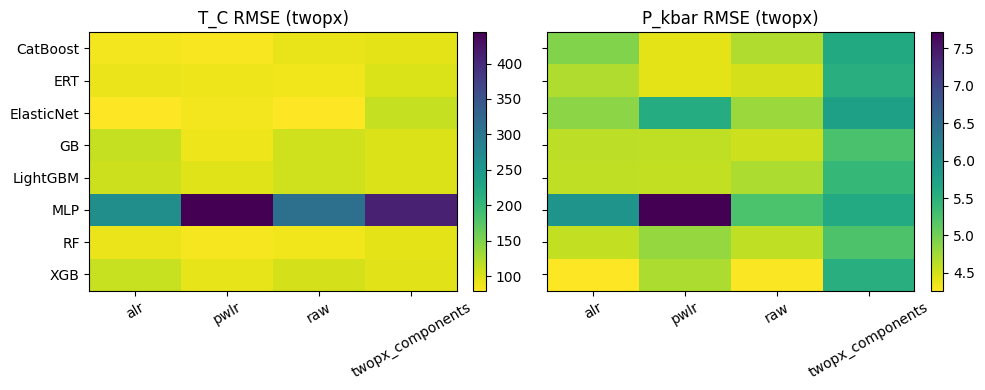

In [6]:
pv = df_bases.pivot_table(index='model', columns=['target','feature_set'],
                          values='test_rmse')
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
for ax, tgt in zip(axes, ['T_C', 'P_kbar']):
    sub = pv[tgt]
    im = ax.imshow(sub.values, aspect='auto', cmap='viridis_r')
    ax.set_xticks(range(sub.shape[1])); ax.set_xticklabels(sub.columns, rotation=30)
    ax.set_yticks(range(sub.shape[0])); ax.set_yticklabels(sub.index)
    ax.set_title(f'{tgt} RMSE (twopx)')
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()


## Figure: test RMSE by model and feature set (bars)


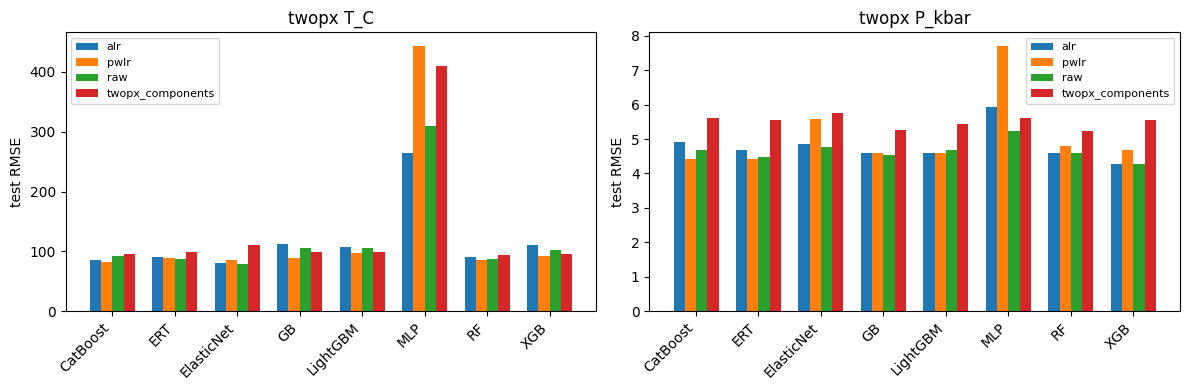

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, tgt in zip(axes, ['T_C', 'P_kbar']):
    sub = df_bases[df_bases['target']==tgt]
    models = sorted(sub['model'].unique())
    fsets = sorted(sub['feature_set'].unique())
    x = np.arange(len(models))
    w = 0.18
    for i, fs in enumerate(fsets):
        vals = [sub[(sub['model']==m) & (sub['feature_set']==fs)]['test_rmse'].values[0]
                for m in models]
        ax.bar(x + (i - len(fsets)/2)*w + w/2, vals, w, label=fs)
    ax.set_xticks(x); ax.set_xticklabels(models, rotation=45, ha='right')
    ax.set_ylabel('test RMSE'); ax.set_title(f'twopx {tgt}')
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


## Test protocol results


In [8]:
from scripts.v10_test_protocol import summarize_tests
tests_df = summarize_tests(pipeline='twopx')
print(f'n_test_rows={len(tests_df)}')
tests_df[['test_id','target','track','passed','value','threshold']].head(60)


n_test_rows=32


,test_id,target,track,passed,value,threshold
0,T01,P_kbar,twopx,True,0.199935,NaN
1,T01,P_kbar,twopx,True,0.317637,NaN
2,T01,P_kbar,twopx,False,-0.000713,NaN
3,T01,P_kbar,twopx,False,-0.032060,NaN
4,T01,T_C,twopx,False,-4.304488,NaN
5,T01,T_C,twopx,True,4.600909,NaN
6,T01,T_C,twopx,True,2.034932,NaN
7,T01,T_C,twopx,False,-0.973792,NaN
8,T02,P_kbar,twopx,False,-0.293611,NaN
9,T02,P_kbar,twopx,False,-0.333426,NaN


In [9]:
if not tests_df.empty:
    rate = tests_df.groupby('test_id')['passed'].agg(['sum', 'count'])
    rate['pass_rate'] = rate['sum'] / rate['count']
    print(rate)


         sum  count  pass_rate
test_id                       
T01        4      8      0.500
T02        3      8      0.375
T11        6      8      0.750
T12        2      8      0.250


## Summary

Phase E twopx training complete. P_kbar twopx RMSE ~4.26 kbar is the best of any opx/cpx track, consistent with the information gain of co-equilibrated phases.
